# SIRDV Model - ORNL Summer 2024
*Goal*<br>

1. Examine the comparative effect of vaccination and social distancing policies on the maximum percent of the population infected from a given disease.<br>
2. Analyze the difference in rate of infections between populations categorized by the type of work they perform (occupational class).

## The Code

In [1]:
#import necessary packages
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

Create a function to define the system of coupled differential equations, which will be solved using implicit euler's method.

In [2]:
def sir_system_implicit(vars, S_prev, I_prev, R_prev, D_prev, V_prev, beta, gamma, death, mu, c, v_rate, econ_impact, distancing_impact, dt, is_development_phase, stay_at_home):
#setup
    S_new, I_new, R_new, D_new, V_new = vars[:3], vars[3:6], vars[6:9], vars[9:12], vars[12:15]

    S_prev, I_prev, R_prev, D_prev, V_prev = np.array(S_prev), np.array(I_prev), np.array(R_prev), np.array(D_prev), np.array(V_prev)

    function = np.zeros(15)

#creating policy adjustments
    #set up adjustable interaction rate, beta, per occupational group
    effective_beta = beta.copy()
    if is_development_phase: #is_development_phase is boolean - if true, vaccine is being developed and interaction rates are higher (lack of vaccine)
        effective_beta[:, 1] *= 1 + econ_impact  # Increase interaction rates for blue-collar workers while vaccine is being worked on
    if stay_at_home: #social distancing policy boolean
        effective_beta[:,1] *= 1 - distancing_impact #Interaction rates for blue collars decreases if social distancing in effect
        effective_beta[:,0] *= 1 - distancing_impact #interaction rates for white collars decreases if social distancing in effect

#creating system of DEs
    function[0:3] = S_new - S_prev + dt * (effective_beta @ I_new * S_new * c - mu * R_new + v_rate * S_new * (1 - is_development_phase))
    function[3:6] = I_new - I_prev - dt * (effective_beta @ I_new * S_new * c - gamma * I_new - death * I_new)
    function[6:9] = R_new - R_prev - dt * (gamma * I_new - mu * R_new - v_rate * R_new * (1 - is_development_phase))
    function[9:12] = D_new - D_prev - dt * death * I_new
    function[12:15] = V_new - V_prev - dt * v_rate * (S_new + R_new) * (1 - is_development_phase)
    
    return function

Now create a function that runs the time loop and optimizes the system for plots later.

In [3]:
def sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold,vaccination_policy_enabled=True,social_dist_policy_enabled=True):
   #establish initial conditions as arrays
    S = np.array(S0)
    I = np.array(I0)
    R = np.array(R0)
    D = np.array(D0)
    V = np.array(V0)

    #establish timesteps
    num_steps = int(T / dt)
    development_steps = int(development_time / dt)

    #establish tracker lists for plots later
    S_list, I_list, R_list, D_list, V_list = [S], [I], [R], [D], [V]

    #the loop over time values
    for i in range(num_steps):
        S_prev, I_prev, R_prev, D_prev, V_prev = S, I, R, D, V 
        
        #vaccine and SD policy toggles
        is_development_phase = (i < development_steps) if vaccination_policy_enabled else True 
        stay_at_home = social_dist_policy_enabled and ((I_prev[0] > stay_threshold) or (I_prev[1] > stay_threshold) or (I_prev[2] > stay_threshold)) #toggles social distancing policy on/off if any one occ class exceeds threshold

        #optimize system using scipy
        sol = opt.root(sir_system_implicit, np.concatenate((S, I, R, D, V)),   
                       args=(S_prev, I_prev, R_prev, D_prev, V_prev, beta, gamma, death, mu, c, v_rate, econ_impact, distancing_impact, dt, is_development_phase, stay_at_home))
        sol = sol.x

        #update tracking lists with solution
        S, I, R, D, V = sol[:3], sol[3:6], sol[6:9], sol[9:12], sol[12:15]
        S_list.append(S)
        I_list.append(I)
        R_list.append(R)
        D_list.append(D)
        V_list.append(V)

    #return tracking lists for plots
    return np.array(S_list), np.array(I_list), np.array(R_list), np.array(D_list), np.array(V_list)

Establish the baseline values for the model. These were arbitrarily chosen for this project.

In [4]:
#THE MODEL

#note-use normalized values (pops sum to 1)
#assume each population is same size

S0 = [0.99, 0.99, 0.99]  # Initial susceptible population
I0 = [0.01, 0.01, 0.01]  # Initial infected population
R0 = [0.0, 0.0, 0.0]     # Initial recovered population
D0 = [0.0, 0.0, 0.0]     # Initial dead population
V0 = [0.0, 0.0, 0.0]     # Initial vaccinated population

#Interaction rates
beta = np.array([[0.25, 0.3, 0.07], # ww, wb, wo
                 [0.5, 0.9, 0.07], # bw, bb, bo
                 [0.06, 0.05, 0.08]]) # ow, ob, oo

# Infection Rate
c = 0.6

# Chance of recovery per day of being infected
gamma = np.array([0.09, 0.09, 0.045]) #white, blue, other

# Death Rates
death = np.array([0.003, 0.004, 0.006]) #white, blue other

# Rates of immunity loss
mu = np.array([0.001, 0.001, 0.0014]) #white, blue other

# Vaccination rate
v_rate = np.array([0.03, 0.01, 0.005]) #white, blue other

# Economic impact of costs of developing vaccine forcing more blue-collar work exposure
econ_impact = 0.4 #(40% increase)

#Impact of social distancing policy (decreases interaction rates by 50%)
distancing_impact = 0.5

#Trigger amount for social distancing policy (goes into effect when any occupational class pop hits 40% infected or more)
stay_threshold = 0.4

#Time parameters
dt = 0.01  # Time step
T = 100    # Total time (days)
development_time = 10  # Time until the vaccine is developed (days)

First, we run the model with both policies and plot each occupational class throughout the epidemic. This ensures the model works appropriately.

In [5]:
#RUNNING THE MODEL - BOTH VACC + SD POLICIES
S_list, I_list, R_list, D_list, V_list = sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold)

time = np.arange(0, T + dt, dt)

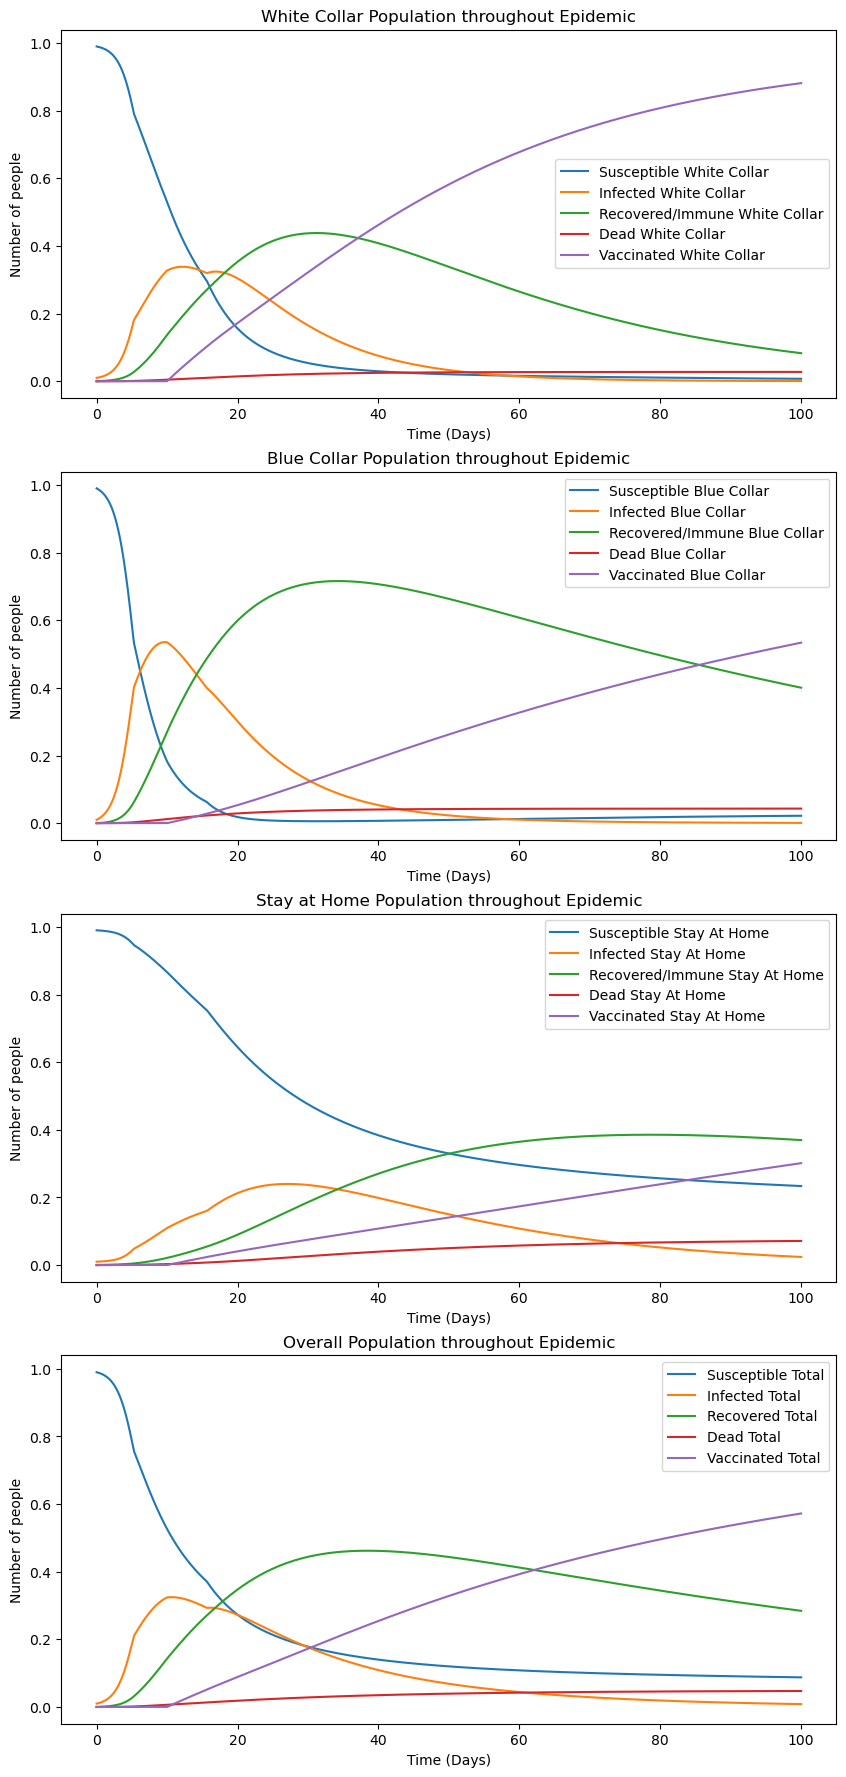

In [6]:
#THE PLOTS - BY OCCUPATIONAL CLASS

#establish plots
fig, ax = plt.subplots(4, 1, figsize=(10, 22))

#plot 1 - White collar over simulation
ax[0].set_title("White Collar Population throughout Epidemic")
ax[0].plot(time, S_list[:, 0], label='Susceptible White Collar')
ax[0].plot(time, I_list[:, 0], label='Infected White Collar')
ax[0].plot(time, R_list[:, 0], label='Recovered/Immune White Collar')
ax[0].plot(time, D_list[:, 0], label='Dead White Collar')
ax[0].plot(time, V_list[:, 0], label='Vaccinated White Collar')

#plot 2 - blue collar over epidemic
ax[1].set_title("Blue Collar Population throughout Epidemic")
ax[1].plot(time, S_list[:, 1], label='Susceptible Blue Collar')
ax[1].plot(time, I_list[:, 1], label='Infected Blue Collar')
ax[1].plot(time, R_list[:, 1], label='Recovered/Immune Blue Collar')
ax[1].plot(time, D_list[:, 1], label='Dead Blue Collar')
ax[1].plot(time, V_list[:, 1], label='Vaccinated Blue Collar')

#plot 3 - other population over epidemic
ax[2].set_title("Stay at Home Population throughout Epidemic")
ax[2].plot(time, S_list[:, 2], label='Susceptible Stay At Home')
ax[2].plot(time, I_list[:, 2], label='Infected Stay At Home')
ax[2].plot(time, R_list[:, 2], label='Recovered/Immune Stay At Home')
ax[2].plot(time, D_list[:, 2], label='Dead Stay At Home')
ax[2].plot(time, V_list[:, 2], label='Vaccinated Stay At Home')

#plot 4
ax[3].set_title("Overall Population throughout Epidemic")
ax[3].plot(time, np.sum(S_list, axis=1) / 3, label='Susceptible Total')
ax[3].plot(time, np.sum(I_list, axis=1) / 3, label='Infected Total')
ax[3].plot(time, np.sum(R_list, axis=1) / 3, label='Recovered Total')
ax[3].plot(time, np.sum(D_list, axis=1) / 3, label='Dead Total')
ax[3].plot(time, np.sum(V_list, axis=1) / 3, label='Vaccinated Total')

for i in range(4):
    ax[i].set_xlabel('Time (Days)')
    ax[i].set_ylabel('Number of people')
    ax[i].legend()

plt.show()

In [7]:
#CALCULATIONS OF MAX PERCENTAGES (for first sim)
print("End: ")
print(f'White Collar: \n Susceptible: {S_list[:,0][-1]} \n Infected: {I_list[:,0][-1]} \n Recovered: {R_list[:,0][-1]} \n Dead: {D_list[:,0][-1]} \n Vaccinated: {V_list[:,1][-1]}')
print(f'Blue Collar: \n Susceptible: {S_list[:,1][-1]} \n Infected: {I_list[:,1][-1]} \n Recovered: {R_list[:,1][-1]} \n Dead: {D_list[:,1][-1]} \n Vaccinated: {V_list[:,1][-1]}')
print(f'Stay at Home: \n Susceptible: {S_list[:,2][-1]} \n Infected: {I_list[:,2][-1]} \n Recovered: {R_list[:,2][-1]} \n Dead: {D_list[:,2][-1]} \n Vaccinated: {V_list[:,2][-1]}')
print(f'Total: \n Suceptible: {np.sum(S_list[-1])/3} \n Infected: {np.sum(I_list[-1])/3} \n Recovered: {np.sum(R_list[-1])/3} \n Dead: {np.sum(D_list[-1])/3} \n Vaccinated: {np.sum(V_list[-1])/3}')

print("")
print(f'Max infected:  \n White Collar: {np.max(I_list[:,0])} \n Blue Collar: {np.max(I_list[:,1])} \n Stay at Home: {np.max(I_list[:,2])} \n Total: {np.max(I_list[:,0] + I_list[:,1] + I_list[:,2])/3}') 

End: 
White Collar: 
 Susceptible: 0.007302952371366418 
 Infected: 0.0005652667077702205 
 Recovered: 0.08299137994508284 
 Dead: 0.027587246807584842 
 Vaccinated: 0.5337185275867751
Blue Collar: 
 Susceptible: 0.02187412188538743 
 Infected: 0.0008254759730406112 
 Recovered: 0.40054088814482586 
 Dead: 0.04304098640997352 
 Vaccinated: 0.5337185275867751
Stay at Home: 
 Susceptible: 0.23367242489120774 
 Infected: 0.024033393846701664 
 Recovered: 0.36952766156297107 
 Dead: 0.07136745093690643 
 Vaccinated: 0.3013990687622143
Total: 
 Suceptible: 0.08761649971598719 
 Infected: 0.008474712175837498 
 Recovered: 0.28435330988429325 
 Dead: 0.04733189471815493 
 Vaccinated: 0.5722235835057286

Max infected:  
 White Collar: 0.33857717791480124 
 Blue Collar: 0.5353874142961063 
 Stay at Home: 0.23994991459647363 
 Total: 0.3247539387226715


# The Results
Now, we run the model in four scenarios: no policy, vaccination only, social distancing only, and both social distancing and vaccination policies. We use the same parameters established above throughout each scenario for reproducibility.

Note: Please run cells in order to get accurate results. The same variable is used repeatedly.
## No Policies

In [8]:
#RUNNING THE MODEL - no policies
S_list, I_list, R_list, D_list, V_list = sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold, vaccination_policy_enabled=False, social_dist_policy_enabled=False)
time = np.arange(0, T + dt, dt)

# Totals (for ease of plotting)
S_total = np.sum(S_list, axis=1) / 3
I_total = np.sum(I_list, axis=1) / 3
R_total = np.sum(R_list, axis=1) / 3
D_total = np.sum(D_list, axis=1) / 3
V_total = np.sum(V_list, axis=1) / 3

# Max infected by group and total
max_white = np.max(I_list[:, 0])
max_blue  = np.max(I_list[:, 1])
max_other = np.max(I_list[:, 2])
max_total = I_total.max()
day_total = time[I_total.argmax()]

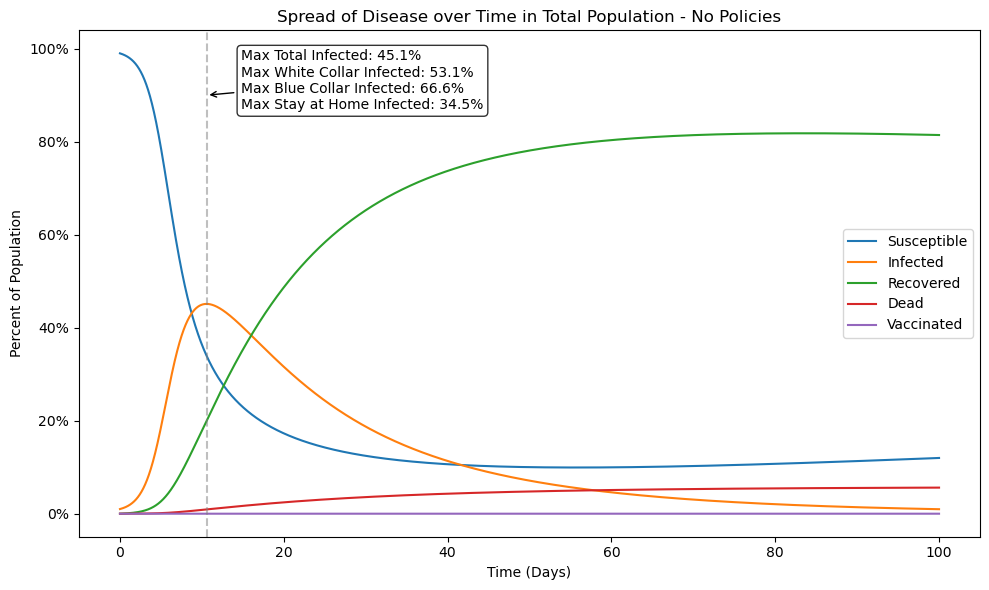

In [9]:
#Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, S_total, label='Susceptible')
ax.plot(time, I_total, label='Infected')
ax.plot(time, R_total, label='Recovered')
ax.plot(time, D_total, label='Dead')
ax.plot(time, V_total, label='Vaccinated')

#label the day of max overall infected population
ax.axvline(day_total, color='gray', linestyle='--', alpha=0.5)

#add specific data
ax.annotate(
    f'Max Total Infected: {max_total:.1%}\n'
    f'Max White Collar Infected: {max_white:.1%}\n'
    f'Max Blue Collar Infected: {max_blue:.1%}\n'
    f'Max Stay at Home Infected: {max_other:.1%}',
    xy=(day_total, .9),
    xytext=(25, -10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.set_xlabel('Time (Days)')
ax.set_ylabel('Percent of Population')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title('Spread of Disease over Time in Total Population - No Policies')
ax.legend()

plt.tight_layout()
plt.show()

## Vaccination Policy Only

In [10]:
#RUNNING THE MODEL - vaccination policy only
S_list, I_list, R_list, D_list, V_list = sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold, vaccination_policy_enabled=True, social_dist_policy_enabled=False)
time = np.arange(0, T + dt, dt)

# Totals (for ease of plotting)
S_total = np.sum(S_list, axis=1) / 3
I_total = np.sum(I_list, axis=1) / 3
R_total = np.sum(R_list, axis=1) / 3
D_total = np.sum(D_list, axis=1) / 3
V_total = np.sum(V_list, axis=1) / 3

# Max infected by group and total
max_white = np.max(I_list[:, 0])
max_blue  = np.max(I_list[:, 1])
max_other = np.max(I_list[:, 2])
max_total = I_total.max()
day_total = time[I_total.argmax()]

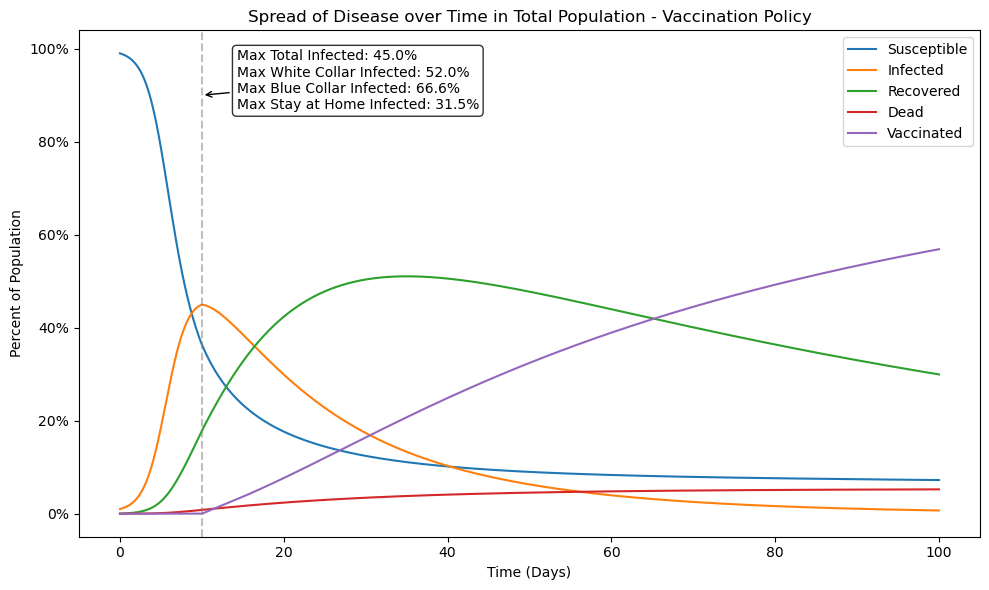

In [11]:
#Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, S_total, label='Susceptible')
ax.plot(time, I_total, label='Infected')
ax.plot(time, R_total, label='Recovered')
ax.plot(time, D_total, label='Dead')
ax.plot(time, V_total, label='Vaccinated')

#label the day of max overall infected population
ax.axvline(day_total, color='gray', linestyle='--', alpha=0.5)

#add specific data
ax.annotate(
    f'Max Total Infected: {max_total:.1%}\n'
    f'Max White Collar Infected: {max_white:.1%}\n'
    f'Max Blue Collar Infected: {max_blue:.1%}\n'
    f'Max Stay at Home Infected: {max_other:.1%}',
    xy=(day_total, .9),
    xytext=(25, -10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.set_xlabel('Time (Days)')
ax.set_ylabel('Percent of Population')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title('Spread of Disease over Time in Total Population - Vaccination Policy')
ax.legend()

plt.tight_layout()
plt.show()

## Social Distancing Policy Only

In [12]:
#RUNNING THE MODEL - SD policy only
S_list, I_list, R_list, D_list, V_list = sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold, vaccination_policy_enabled=False, social_dist_policy_enabled=True)
time = np.arange(0, T + dt, dt)

# Totals (for ease of plotting)
S_total = np.sum(S_list, axis=1) / 3
I_total = np.sum(I_list, axis=1) / 3
R_total = np.sum(R_list, axis=1) / 3
D_total = np.sum(D_list, axis=1) / 3
V_total = np.sum(V_list, axis=1) / 3

# Max infected by group and total
max_white = np.max(I_list[:, 0])
max_blue  = np.max(I_list[:, 1])
max_other = np.max(I_list[:, 2])
max_total = I_total.max()
day_total = time[I_total.argmax()]

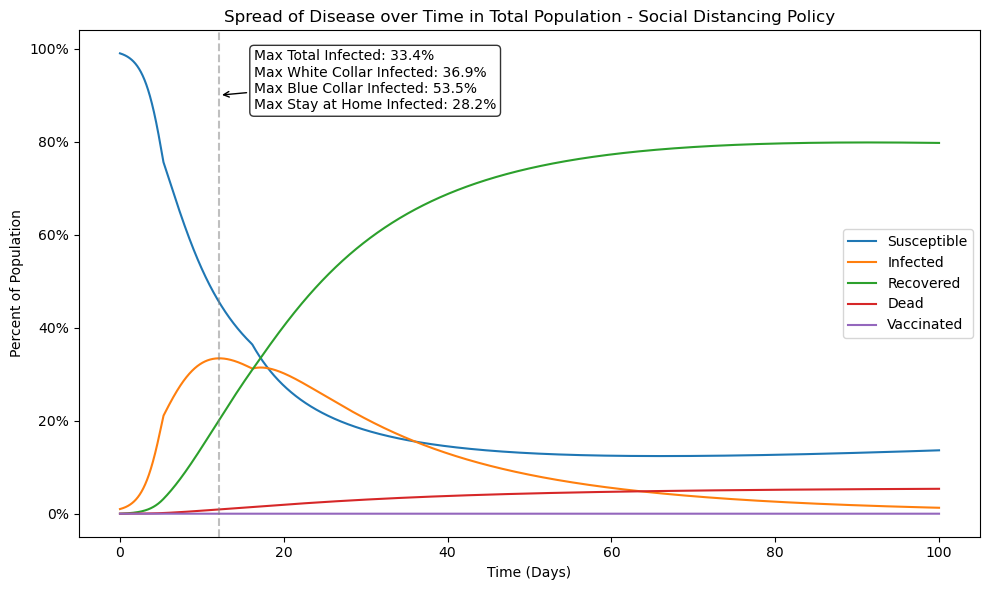

In [13]:
#Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, S_total, label='Susceptible')
ax.plot(time, I_total, label='Infected')
ax.plot(time, R_total, label='Recovered')
ax.plot(time, D_total, label='Dead')
ax.plot(time, V_total, label='Vaccinated')

#label the day of max overall infected population
ax.axvline(day_total, color='gray', linestyle='--', alpha=0.5)

#add specific data
ax.annotate(
    f'Max Total Infected: {max_total:.1%}\n'
    f'Max White Collar Infected: {max_white:.1%}\n'
    f'Max Blue Collar Infected: {max_blue:.1%}\n'
    f'Max Stay at Home Infected: {max_other:.1%}',
    xy=(day_total, .9),
    xytext=(25, -10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.set_xlabel('Time (Days)')
ax.set_ylabel('Percent of Population')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title('Spread of Disease over Time in Total Population - Social Distancing Policy')
ax.legend()

plt.tight_layout()
plt.show()

## Both Vaccination and Social Distancing Policies

In [14]:
#RUNNING THE MODEL - SD and vacc policy
S_list, I_list, R_list, D_list, V_list = sir_model_implicit_euler_matrix(S0, I0, R0, D0, V0, beta, gamma, dt, death, mu, v_rate, econ_impact, distancing_impact, T, c, development_time, stay_threshold, vaccination_policy_enabled=True, social_dist_policy_enabled=True)
time = np.arange(0, T + dt, dt)

# Totals (for ease of plotting)
S_total = np.sum(S_list, axis=1) / 3
I_total = np.sum(I_list, axis=1) / 3
R_total = np.sum(R_list, axis=1) / 3
D_total = np.sum(D_list, axis=1) / 3
V_total = np.sum(V_list, axis=1) / 3

# Max infected by group and total
max_white = np.max(I_list[:, 0])
max_blue  = np.max(I_list[:, 1])
max_other = np.max(I_list[:, 2])
max_total = I_total.max()
day_total = time[I_total.argmax()]

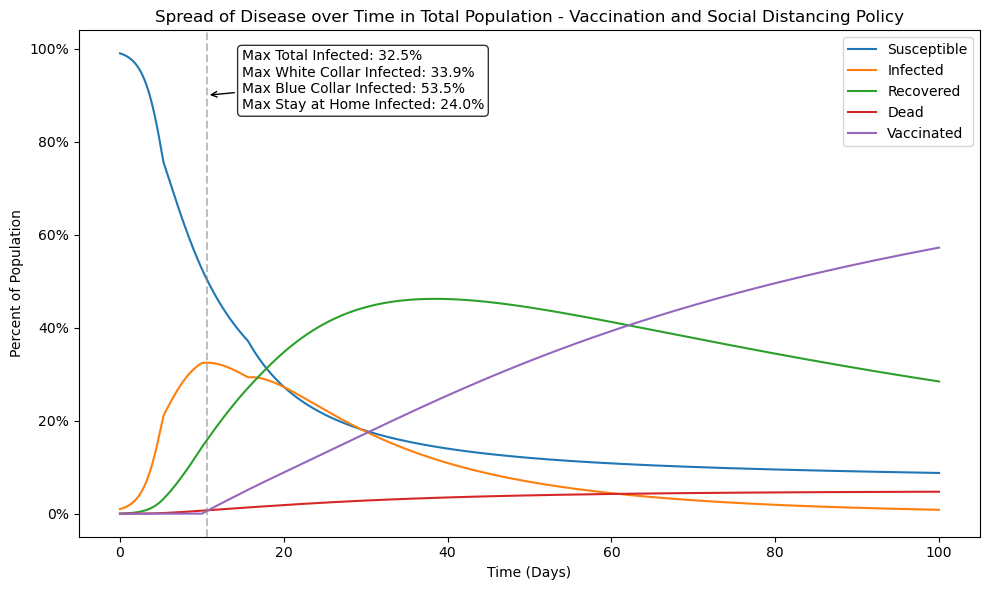

In [15]:
#Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(time, S_total, label='Susceptible')
ax.plot(time, I_total, label='Infected')
ax.plot(time, R_total, label='Recovered')
ax.plot(time, D_total, label='Dead')
ax.plot(time, V_total, label='Vaccinated')

#label the day of max overall infected population
ax.axvline(day_total, color='gray', linestyle='--', alpha=0.5)

#add specific data
ax.annotate(
    f'Max Total Infected: {max_total:.1%}\n'
    f'Max White Collar Infected: {max_white:.1%}\n'
    f'Max Blue Collar Infected: {max_blue:.1%}\n'
    f'Max Stay at Home Infected: {max_other:.1%}',
    xy=(day_total, .9),
    xytext=(25, -10), textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

ax.set_xlabel('Time (Days)')
ax.set_ylabel('Percent of Population')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_title('Spread of Disease over Time in Total Population - Vaccination and Social Distancing Policy')
ax.legend()

plt.tight_layout()
plt.show()